<h1><center>Movie Recommendation System - Exploratory  Data Analysis</center></h1>

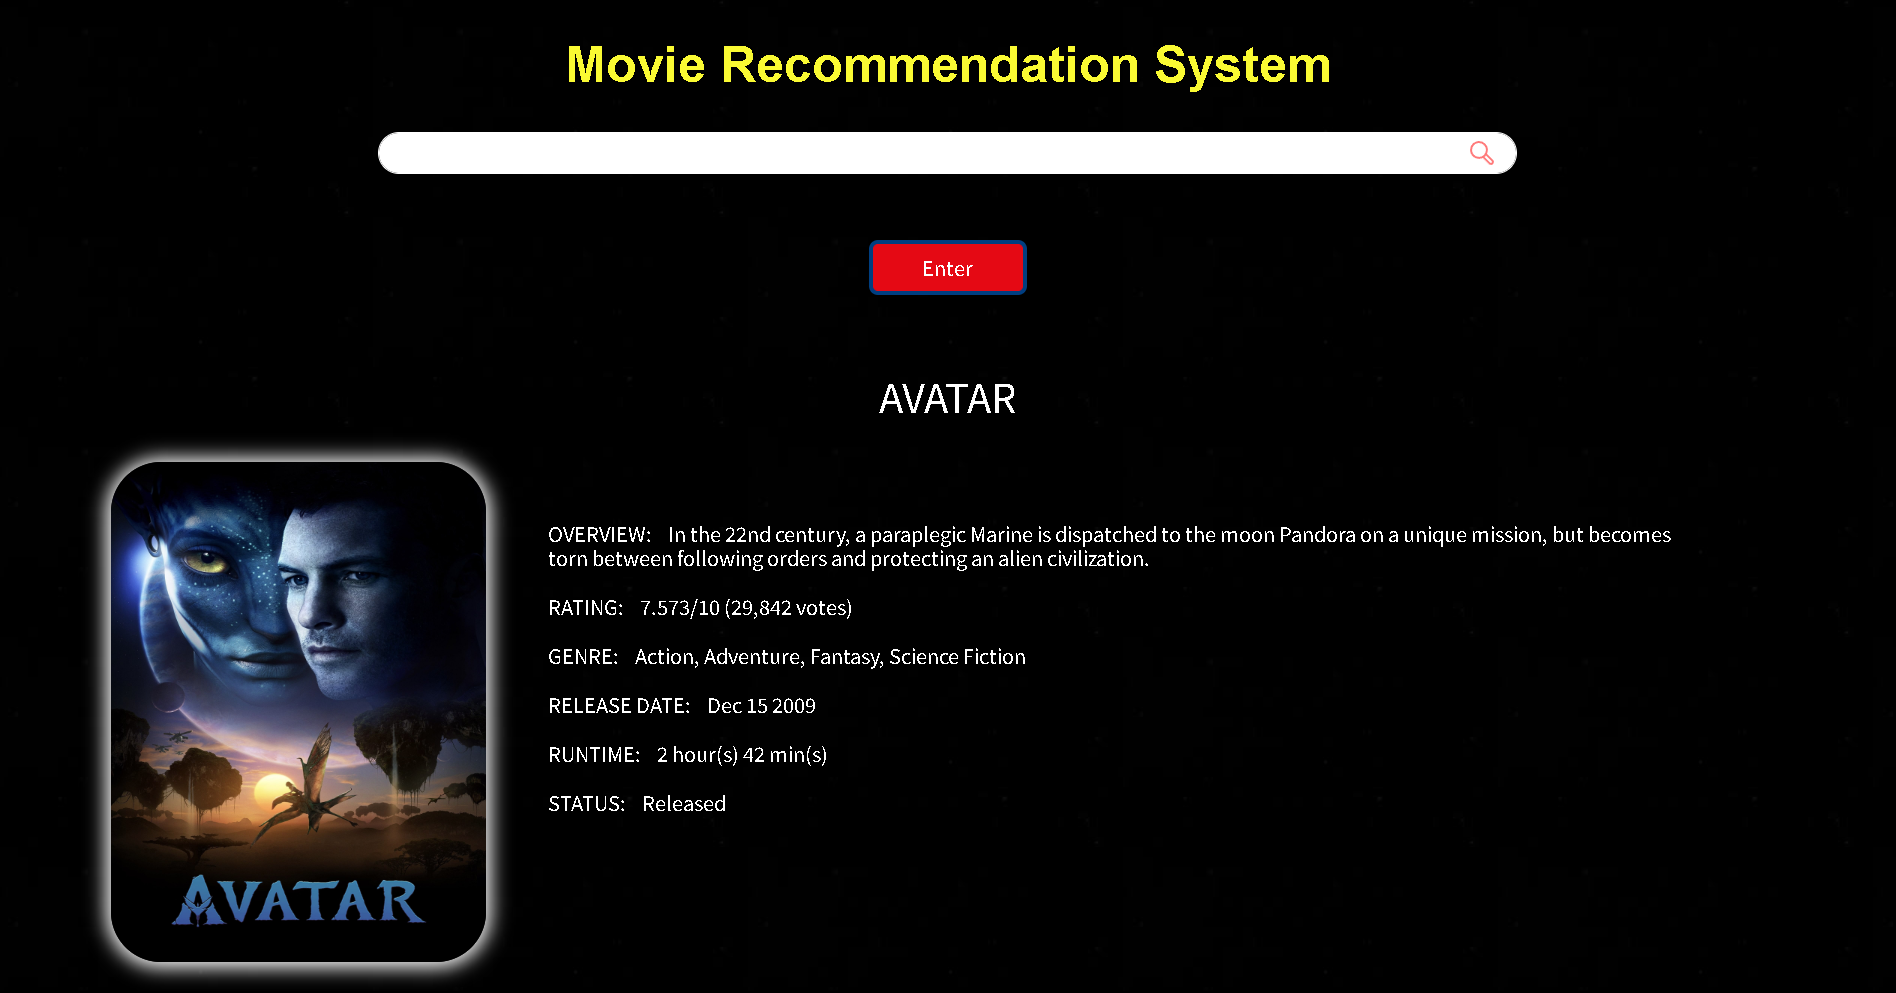

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Cosine Similarity Calculation
- Ranking and Recommendations
- Deployment

<p> We Will Perform upto Exploratory Data Analysis in this Notebook <p>

### 1) Problem statement
- This project Creates a content-based movie recommendation system using cosine similarity to address the challenge of personalizing movie recommendations based on user preferences and rich movie attributes.


### 2) Data Collection
- Dataset Source - <a href="https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies" target="_blank" rel="noopener"> Dataset Link </a>
<br>

- The data consists of 28 columns and 1162949 Records/Rows.

# 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('../Artifacts/main_data.csv')

In [4]:
df.head()

,director_name,actor_1_name,actor_2_name,actor_3_name,genres,movie_title,comb
0,Christopher Nolan,Kristian Van der Heyden,Alexander Michael Helisek,Russ Fega,Adventure Drama Science Fiction,interstellar,Kristian Van der Heyden Alexander Michael Heli...
1,Christopher Nolan,Silvie Laguna,Talulah Riley,Magnus Nolan,Action Science Fiction Adventure,inception,Silvie Laguna Talulah Riley Magnus Nolan Chris...
2,Joss Whedon,Eric Frank,Walter Perez,Rashmi Rustagi,Science Fiction Action Adventure,the avengers,Eric Frank Walter Perez Rashmi Rustagi Joss Wh...
3,Christopher Nolan,Edison Chen,Will Zahrn,Buster Reeves,Action Crime Thriller,the dark knight,Edison Chen Will Zahrn Buster Reeves Christoph...
4,James Cameron,Haniyyah Tahirah,Sonia Yee,Sara Wilson,Action Adventure Fantasy Science Fiction,avatar,Haniyyah Tahirah Sonia Yee Sara Wilson James C...


### Shape of the Dataset

In [5]:
df.shape

(15000, 7)

# 2.2 Dataset Information

- Director_Name    :Movie director's name
- Actor_1_Name     : Primary lead actor/actress
- Actor_2_Name     : Secondary lead actor/actress
- Actor_3_Name     : Tertiary actor/actress
- Genres           : Movie's thematic categories
- Movie_Title      : Title of the movie
- Combined_Feature : Aggregate representation for recommendation

### 3). Data Checks to perform

- Checking Missing values
- Checking Duplicates
- Checking data type
- Checking the number of unique values of each column
- Checking statistics of data set
- Checking Categorical and Numerical Attributes
- Checking various categories present in the different categorical column

### 3.1 Check Missing values

In [6]:
df.isnull().sum()

director_name    0
actor_1_name     0
actor_2_name     0
actor_3_name     0
genres           0
movie_title      0
comb             0
dtype: int64

## Insights:

- There are no Missing Values in the dataset

### 3.2 Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

## Insights:

- There are no duplicates  values in the data set

### 3.3 Check data types

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   director_name  15000 non-null  str  
 1   actor_1_name   15000 non-null  str  
 2   actor_2_name   15000 non-null  str  
 3   actor_3_name   15000 non-null  str  
 4   genres         15000 non-null  str  
 5   movie_title    15000 non-null  str  
 6   comb           15000 non-null  str  
dtypes: str(7)
memory usage: 820.4 KB


## Insights:

- All Features are in Object Datatype

### 3.4 Checking the number of unique values of each column

In [9]:
df.nunique()

director_name     6115
actor_1_name     13299
actor_2_name     13496
actor_3_name     13484
genres            2835
movie_title      14332
comb             14988
dtype: int64

## Insights:

- All Features are having Number of Classes

### 3.5 Checking statistics of data set

In [10]:
df.describe()

,director_name,actor_1_name,actor_2_name,actor_3_name,genres,movie_title,comb
count,15000,15000,15000,15000,15000,15000,15000
unique,6115,13299,13496,13484,2835,14332,14988
top,Woody Allen,unknown,unknown,unknown,Comedy,return,Dave Chappelle unknown unknown Stan Lathan Comedy
freq,49,33,92,139,926,16,6


### 3.5 Categorical and Numerical Attributes

In [11]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 7 numerical features : ['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name', 'genres', 'movie_title', 'comb']

We have 0 categorical features : []


## Insights:

- All are Categorical Features (No Numerical Attributes)

### 3.6 Checking Various Categories Present in the Different Categorical Column

In [12]:
print("Categories in Directors:     ",end=" " )
print(df['director_name'].unique())

print("\nCategories in Actor 1:  ",end=" ")
print(df['actor_1_name'].unique())

print("\nCategories in'Actor 2:",end=" " )
print(df['actor_2_name'].unique())

print("\nCategories in Actor 3:     ",end=" " )
print(df['actor_3_name'].unique())

print("\nCategories in Genres:     ",end=" " )
print(df['genres'].unique())

Categories in Directors:      <StringArray>
[   'Christopher Nolan',          'Joss Whedon',        'James Cameron',
           'Tim Miller',            'Joe Russo',        'David Fincher',
       'Frank Darabont',    'Quentin Tarantino',           'James Gunn',
      'Robert Zemeckis',
 ...
          'Dean Alioto',           'Vadim Jean',      'Carmine Gallone',
        'Philippe Muyl',         'Michel Blanc',         'Lola Doillon',
      'Stanton Barrett',        'Meghna Gulzar',          'Ray Kellogg',
 'Richard Kwietniowski']
Length: 6115, dtype: str

Categories in Actor 1:   <StringArray>
['Kristian Van der Heyden',           'Silvie Laguna',
              'Eric Frank',             'Edison Chen',
        'Haniyyah Tahirah',           'Leslie Uggams',
          'Ameenah Kaplan',               'Brad Pitt',
           'Bill Bolender',        'Rosanna Arquette',
 ...
        'Yasuko Matsuyuki',             'Enzo Maggio',
        'Irene Cassanelli',             'Neeraj Kabi',
        

## Insights:

- There are Alot of Classes in each Feature

### 4). Exploratory Data Analysis ( Visualization )

## 4.1 Genre Distribution

In [13]:
genre_df = df['genres'].str.split(' ', expand=True).stack().reset_index(level=1, drop=True).rename('genre')
genre_counts = genre_df.value_counts().tolist()
unique_genres = genre_df.unique().tolist()

In [22]:
print(type(unique_genres[0]))
print(unique_genres[:10])

<class 'str'>
['Adventure', '', 'Drama', 'Science', 'Fiction', nan, 'Action', 'Crime', 'Thriller', 'Fantasy']


In [32]:
unique_genres_clean = []
genre_counts_clean = []

for g, c in zip(unique_genres, genre_counts):
    if pd.notna(g) and g != '':
        unique_genres_clean.append(g)
        genre_counts_clean.append(c)

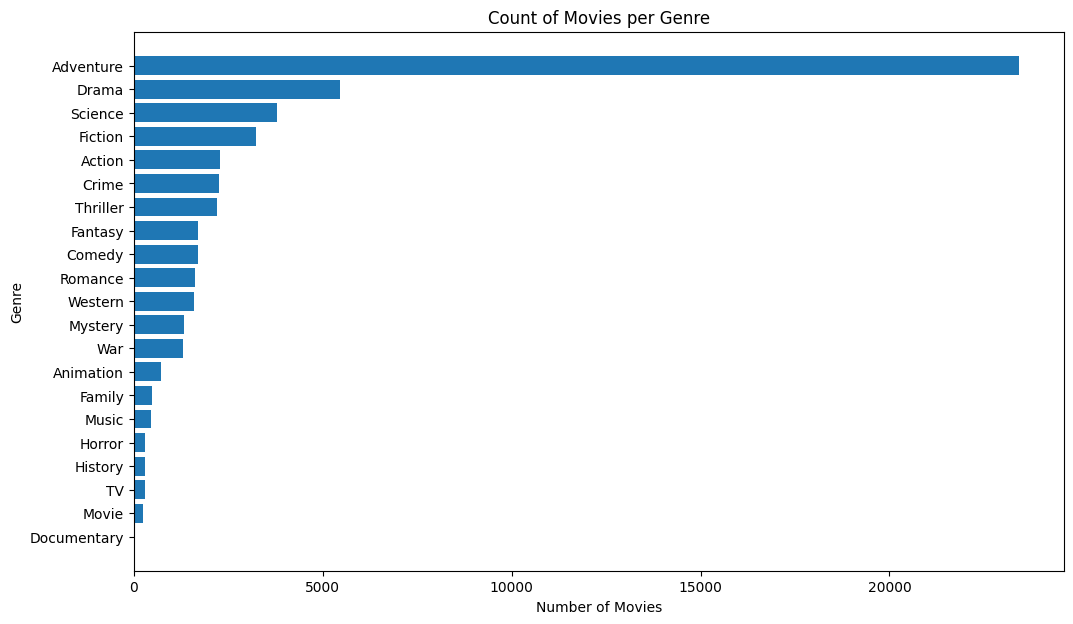

In [34]:
plt.figure(figsize=(12,7))
plt.barh(unique_genres_clean, genre_counts_clean)
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Count of Movies per Genre")
plt.gca().invert_yaxis()
plt.show()

## Insights:

- <h3>Most Frequent Genre:</h3> <br> 1. Action <br><br> 2. Adventure

## 4.2 Top 10 Actors (Actor_1)

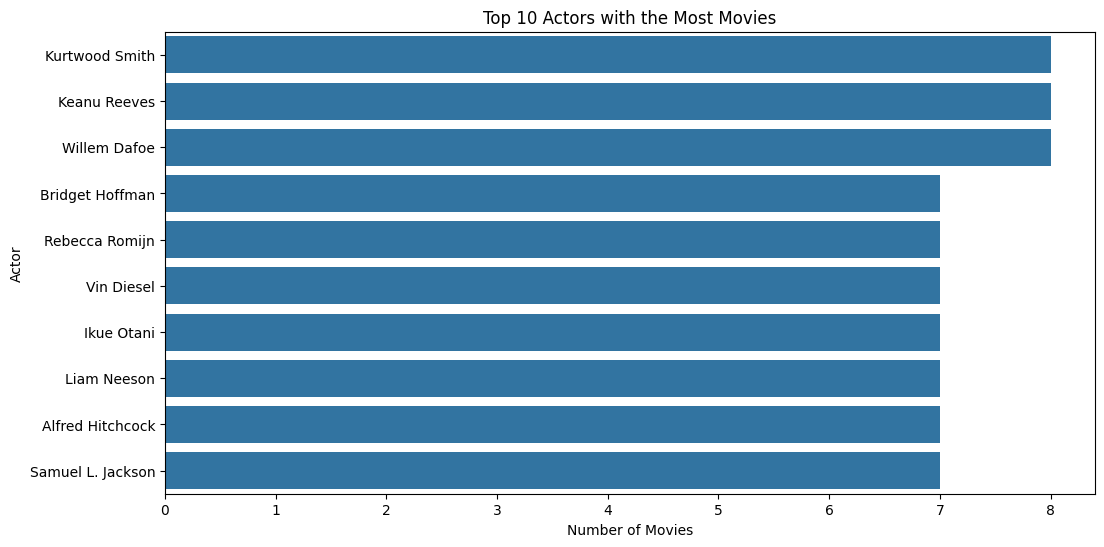

In [37]:
top_actors = df[df['actor_1_name'] != 'unknown']['actor_1_name'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_actors.values, y=top_actors.index)
plt.title("Top 10 Actors with the Most Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Actor")
plt.show()

## Insights:

- Top 1 Actor: Robert De Niro
    

## 4.3 Top 10 Genres

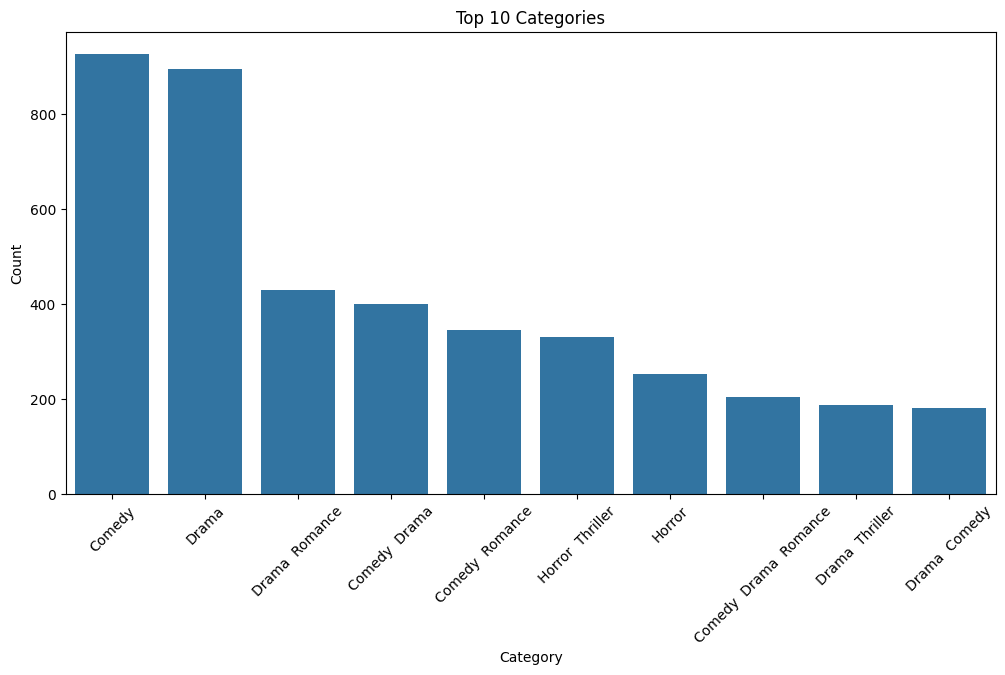

In [38]:
top_categories = df['genres'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.xticks(rotation=45)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title(f'Top {10} Categories')
plt.show()

## Insights: 


- Drama Alone is Most Frequent Genre    

## 4.4 Top Directors 

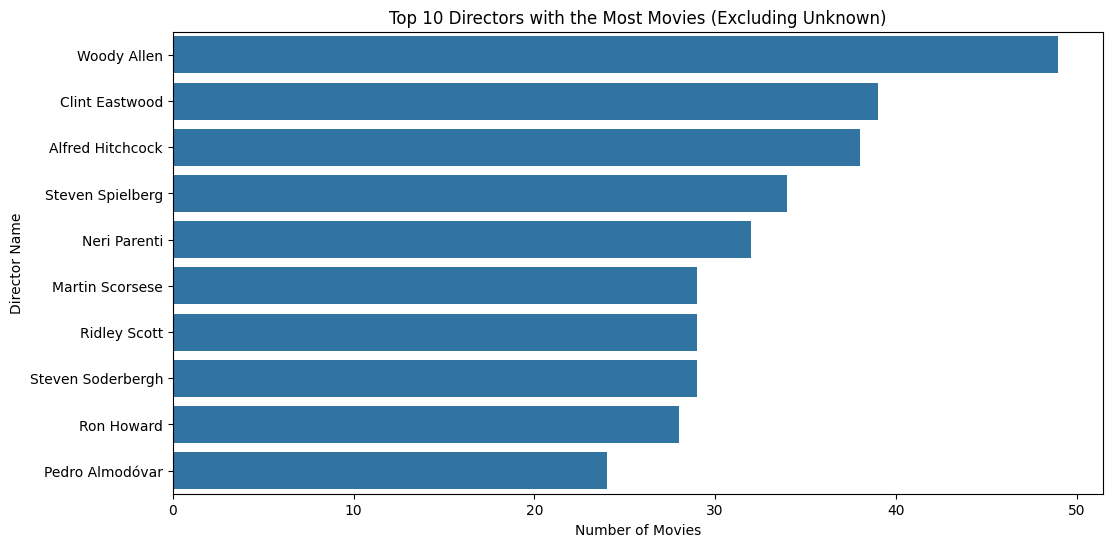

In [39]:
filtered_df = df[df['director_name'] != 'unknown']
top_directors = filtered_df['director_name'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.xlabel('Number of Movies')
plt.ylabel('Director Name')
plt.title(f'Top {10} Directors with the Most Movies (Excluding Unknown)')
plt.show()

## Insights:

- Steven Speilberg, The Director With most Movies

## 4.5 Movie Titles Word Cloud - Word Cloud

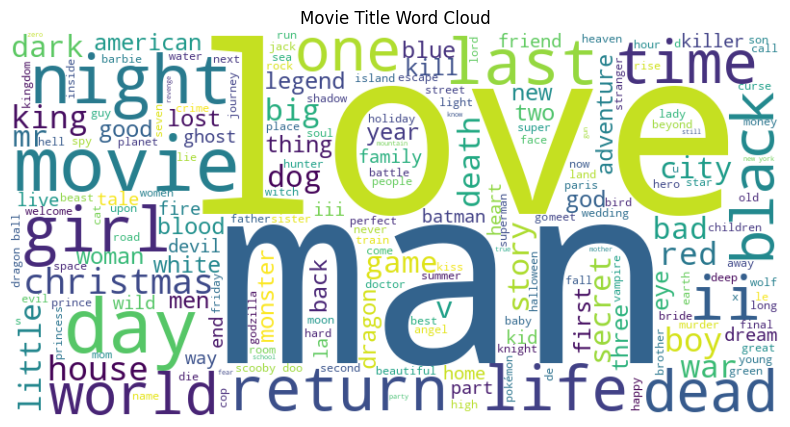

In [40]:
from wordcloud import WordCloud

wordcloud_text = ' '.join(df['movie_title'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(wordcloud_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Movie Title Word Cloud')
plt.show()

## Insights:

- Most Frequently Used Words: Love, Last, Man, Day

## 4.6 Distribution of Categorical and Numerical Features

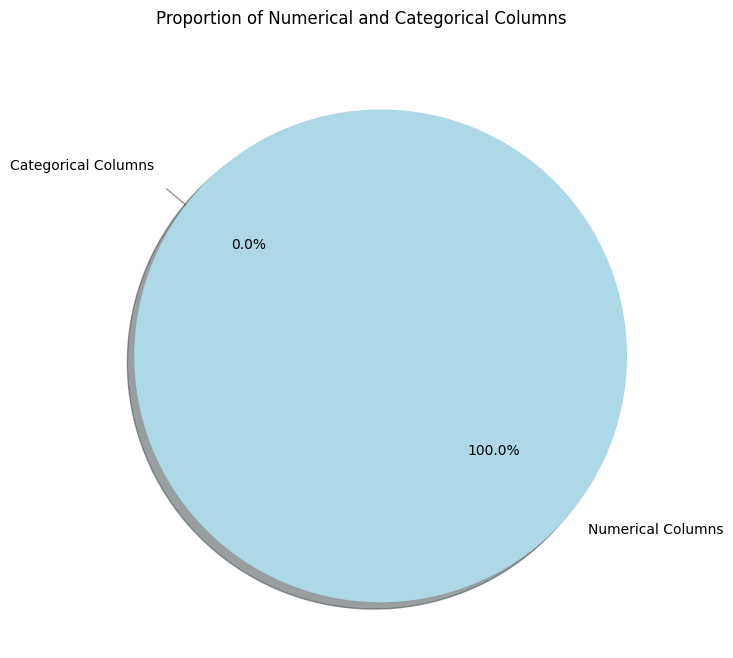

In [41]:
num_numerical_columns = len(numeric_features)
num_categorical_columns = len(categorical_features)

labels = ['Numerical Columns', 'Categorical Columns']
sizes = [num_numerical_columns, num_categorical_columns]
colors = ['lightblue', 'lightcoral']
explode = (0.1, 0)
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Proportion of Numerical and Categorical Columns')
plt.show()

## Insights:

- All are Categorical Attributes Only

## 4.7 Director-Actor Collaborations by Number of Movies

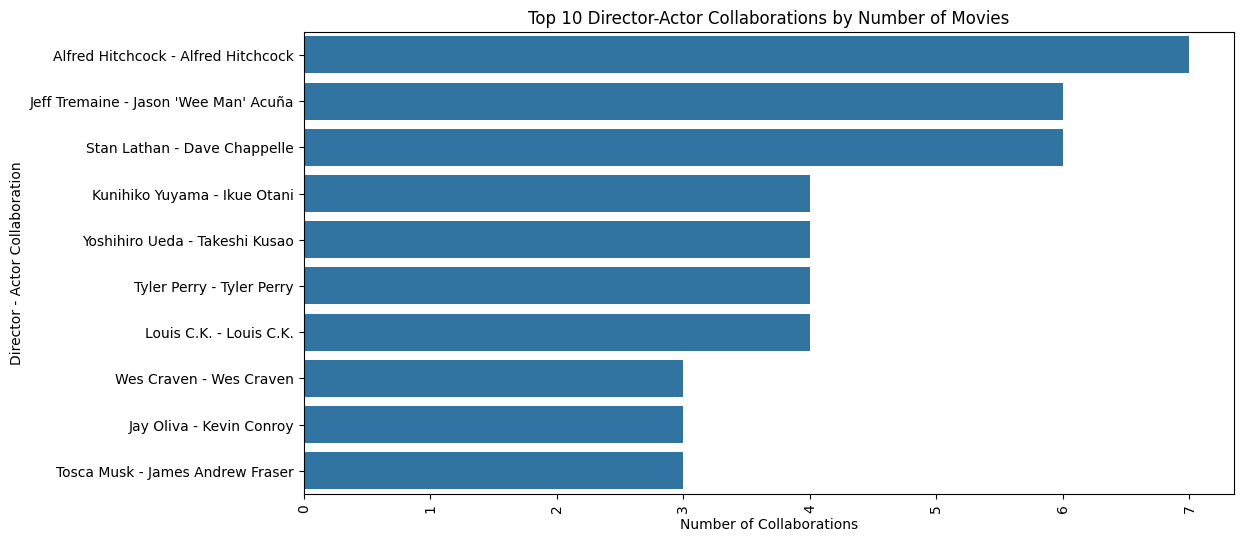

In [42]:
df['director_actor_collaboration'] = df['director_name'] + ' - ' + df['actor_1_name']
collaboration_counts = df['director_actor_collaboration'].value_counts()
top_10_collaborations = collaboration_counts.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_collaborations.values, y=top_10_collaborations.index)
plt.xlabel('Number of Collaborations')
plt.ylabel('Director - Actor Collaboration')
plt.title('Top 10 Director-Actor Collaborations by Number of Movies')
plt.xticks(rotation=90)
plt.show()

## Insights:

- Most Collaborated Director and Actor: Clint EastWood

## 4.8 Actor-Genre Relationships

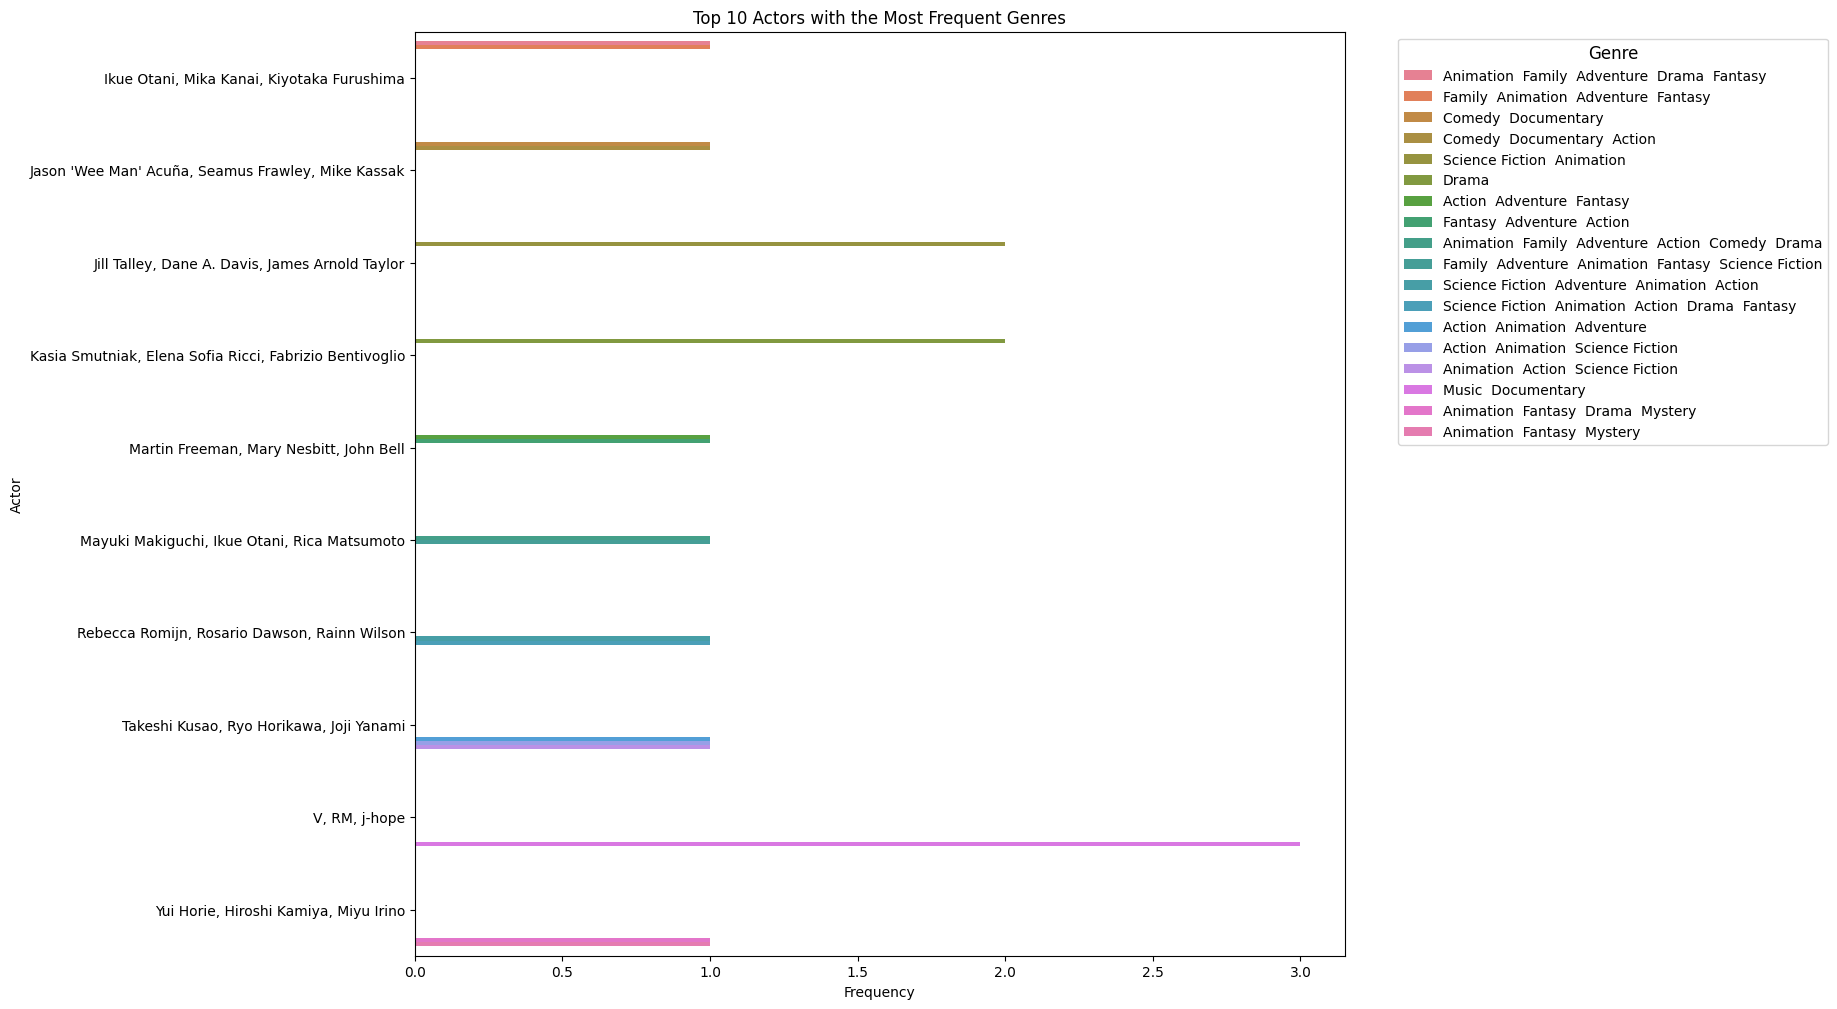

In [ ]:
actor_columns = ['actor_1_name', 'actor_2_name', 'actor_3_name']
df['actors'] = df[actor_columns].apply(lambda x: ', '.join(x.dropna().astype(str)), axis=1)

df = df[
(df['actor_1_name'].notna()) &
(df['actor_1_name'] != 'unknown') &
(df['actor_2_name'] != 'unknown') &
(df['actor_3_name'] != 'unknown')
]

df['actors'] = df[actor_columns].apply(lambda x: ', '.join(x.dropna().astype(str)), axis=1)

# Split the genres and create a new DataFrame with one row per genre-actor pair
genre_actor_df = df['genres'].str.split('|', expand=True).stack().reset_index(level=1, drop=True).rename('genre')
genre_actor_df = pd.concat([genre_actor_df, df['actors']], axis=1)

# Count the occurrences of each Actor-Genre combination
actor_genre_counts = genre_actor_df.groupby(['actors', 'genre']).size().reset_index(name='count')

# Find the top 10 actors who appeared in the most frequent genres
top_10_actors = actor_genre_counts.groupby('actors')['count'].sum().nlargest(10).index

# Create a count plot to visualize the top 10 actors who played the most frequent genres
plt.figure(figsize=(12, 12))
sns.barplot(x='count', y='actors', hue='genre', data=actor_genre_counts[actor_genre_counts['actors'].isin(top_10_actors)])
plt.title('Top 10 Actors with the Most Frequent Genres')
plt.xlabel('Frequency')
plt.ylabel('Actor')
plt.legend(title='Genre', title_fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Insights:


- Most Frequent Actor-Genre Relationship: V, RM, j-hope - Animation Fantasy Drama Mystery